<a href="https://colab.research.google.com/github/toplubster/Biocoding-Stuffs-/blob/main/MD_version8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ══ CELL 1: Install all packages ═════════════════════════════════════════════
# Run once, then Runtime > Restart session

!pip install -q py3dmol rdkit MDAnalysis meeko vina gemmi
!apt-get install -q -y openbabel      # used ONLY for protein → PDBQT (not ligand)

# Install AutoDock Vina executable
!rm -f vina autodock_vina_1_2_3_linux_x86_64 # Ensure previous downloads are removed
!wget -qnc https://vina.scripps.edu/wp-content/releases/autodock_vina_1_2_3_linux_x86_64 -O vina
!chmod +x vina
!mv vina /usr/local/bin/vina

# PLIP installation
!rm -rf plip
!git clone -b master https://github.com/pharmai/plip.git
!sed -i '23d' plip/setup.py
!pip install -e plip

# Configuration
PDB_ID         = "1HVR"
ligand_resname = "XK2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.8 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libboost-iostreams1.74.0 libinchi1 libmaeparser1 libopenbabel7
The following NEW packages will be installed:
  libboost-iostreams1.74.0 libinchi1 libmaeparser1 libopenbabel7 openbabel
0 upgraded, 5 newly installed, 0 to remove and 3 n

In [2]:
# ══ CELL 2: ALL imports — do not import anywhere else in the notebook ══════════

# Standard library
import os, re, copy, json, shutil, subprocess
import uuid as _uuid
from io import BytesIO

# Scientific
import numpy as np
import requests
import matplotlib.pyplot as plt

# Molecular tools
import py3Dmol
import MDAnalysis as mda

# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit.Chem.Draw import MolToImage

# Jupyter
import ipywidgets as widgets
from IPython.display import display, HTML, Image, clear_output

print("✅ All packages imported")

✅ All packages imported


In [3]:
# ══ CELL 3: Download PDB and initial visualisation ════════════════════════════

resp = requests.get(f'https://files.rcsb.org/download/{PDB_ID}.pdb')
resp.raise_for_status()
with open(f'{PDB_ID}.pdb', 'w') as f:
    f.write(resp.text)
print(f'Downloaded {PDB_ID}.pdb')

view = py3Dmol.view(query=f'pdb:{PDB_ID}', width=800, height=600)
view.setStyle({'cartoon': {'color': 'spectrum'}})
view.zoomTo()
view.show()

Downloaded 1HVR.pdb


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Ligand 'XK2': 46 atoms → ligand.pdb


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(


RCSB SDF heavy atoms : 46
SMILES               : O=C1N(Cc2ccc3ccccc3c2)[C@H](Cc2ccccc2)[C@H](O)[C@@H](O)[C@@H](Cc2ccccc2)N1Cc1ccc2ccccc2c1


[13:51:24] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


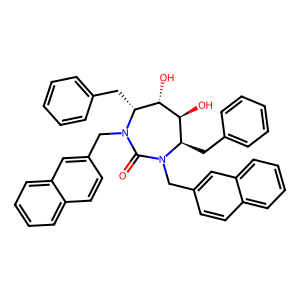

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [4]:
# ══ CELL 4: Extract ligand + build mol with correct bond orders ════════════════
#
# ─── IMPORTANT ────────────────────────────────────────────────────────────────
#  mol  is assigned EXACTLY ONCE here (from RCSB SDF → correct bond orders).
#  Nothing else in this notebook should ever assign to the name 'mol'.
#  The protein prep cell previously overwrote mol with the whole protein —
#  that was the root cause of the 1826 vs 46 atom mismatch. Fixed in Cell 10.
# ──────────────────────────────────────────────────────────────────────────────

def get_mol_from_rcsb_sdf(ligand_id):
    """Download ideal SDF from RCSB — bond orders are explicit in SDF format."""
    url = f"https://files.rcsb.org/ligands/download/{ligand_id}_ideal.sdf"
    r   = requests.get(url)
    r.raise_for_status()
    supplier = Chem.SDMolSupplier()
    supplier.SetData(r.text)
    return next(iter(supplier), None)

# ── extract co-crystallised ligand ────────────────────────────────────────────
universe         = mda.Universe(f'{PDB_ID}.pdb')
ligand_selection = universe.select_atoms(f'resname {ligand_resname}')

if ligand_selection.n_atoms == 0:
    raise ValueError(f"Ligand '{ligand_resname}' not found in {PDB_ID}.pdb")

ligand_selection.write('ligand.pdb')
print(f"Ligand '{ligand_resname}': {ligand_selection.n_atoms} atoms → ligand.pdb")

# ── fetch mol with correct bond orders ── THE ONLY ASSIGNMENT TO mol ──────────
mol = get_mol_from_rcsb_sdf(ligand_resname)
if mol is None:
    raise ValueError(f"Could not fetch SDF for {ligand_resname} from RCSB")

print(f"RCSB SDF heavy atoms : {mol.GetNumAtoms()}")
print(f"SMILES               : {Chem.MolToSmiles(mol)}")

# 2D preview
_preview = copy.deepcopy(mol)
AllChem.Compute2DCoords(_preview)
display(Draw.MolToImage(_preview, size=(300, 300)))

# 3D visualisation — protein + ligand
view = py3Dmol.view(width=800, height=600)
view.addModel(open(f'{PDB_ID}.pdb').read(), 'pdb')
view.setStyle({'cartoon': {'color': 'spectrum'}})
view.addModel(open('ligand.pdb').read(), 'pdb')
view.setStyle({'resn': ligand_resname}, {'stick': {}})
view.zoomTo()
view.show()

### Dynamic Interaction Residue List

This cell generates a list of interacting residues based on the geometric contact analysis performed in the previous cell. This list can be used in place of a hardcoded `important_residues` list.

In [5]:
#CELL 5: Docking tools check ═══════════════════════════════════════════════

import shutil

def _check(tool):
    # Check for the specific executable named 'vina'
    found = shutil.which(tool) is not None
    print(f"  {'✅' if found else '❌'}  {tool}: {'found' if found else 'NOT FOUND'}")

print("Checking tools:")
_check("vina") # Check for the 'vina' executable
_check("obabel")   # ← needed only for protein PDBQT conversion
print("\nAll checks done.")

Checking tools:
  ✅  vina: found
  ✅  obabel: found

All checks done.


In [6]:
# ══ CELL 6: Prepare protein for docking ══════════════════════════════════════
#
# FIX: The original code assigned  mol = Chem.MolFromPDBFile('protein_clean.pdb')
#      inside the RDKit fallback, overwriting the ligand mol (46 atoms) with the
#      entire protein (1826 atoms). Fixed by using  protein_mol  throughout this cell.

print("Step 1: Stripping water and HETATM records...")
with open(f'{PDB_ID}.pdb') as f:
    lines = f.readlines()

protein_lines = [l for l in lines
                 if l.startswith('ATOM') or l.startswith('TER') or l.startswith('END')]
with open('protein_clean.pdb', 'w') as f:
    f.writelines(protein_lines)
print(f"  Kept {len(protein_lines)} lines → protein_clean.pdb")

# ── add hydrogens ─────────────────────────────────────────────────────────────
print("\nStep 2: Adding hydrogens...")
protein_h_file_created = False
try:
    # Attempt using 'reduce' command-line tool
    result = subprocess.run(
        ['reduce', '-NOFLIP', 'protein_clean.pdb'],
        capture_output=True, text=True, check=True)
    if result.stdout.strip():
        with open('protein_H.pdb', 'w') as f:
            f.write(result.stdout)
        print("  Used 'reduce' → protein_H.pdb")
        protein_h_file_created = True
    else:
        print("  'reduce' returned empty output. Attempting RDKit fallback...")
except (FileNotFoundError, subprocess.CalledProcessError) as e:
    print(f"  'reduce' command failed or not found ({e}). Attempting RDKit fallback...")
except Exception as e:
    print(f"  Unexpected error with 'reduce' ({e}). Attempting RDKit fallback...")

# If 'reduce' failed, try RDKit fallback
if not protein_h_file_created:
    try:
        protein_mol = Chem.MolFromPDBFile(
            'protein_clean.pdb', removeHs=False, sanitize=False)
        if protein_mol is None:
            raise ValueError("RDKit could not parse protein_clean.pdb")
        protein_mol_h = Chem.AddHs(protein_mol, addCoords=True)
        Chem.MolToPDBFile(protein_mol_h, 'protein_H.pdb')
        print("  Used RDKit AddHs → protein_H.pdb")
        protein_h_file_created = True
    except Exception as rdkit_err:
        print(f"  RDKit fallback failed ({rdkit_err}). Copying protein_clean.pdb to protein_H.pdb as-is (less accurate).")
        # Fallback to copy if RDKit also fails
        shutil.copy('protein_clean.pdb', 'protein_H.pdb')
        protein_h_file_created = True

# Final safeguard: if protein_H.pdb is still not created, copy protein_clean.pdb
if not protein_h_file_created or not os.path.exists('protein_H.pdb'):
    print("  Failed to create protonated protein_H.pdb by any method. Copying protein_clean.pdb as protein_H.pdb as a last resort.")
    shutil.copy('protein_clean.pdb', 'protein_H.pdb')
    protein_h_file_created = True

# ── convert protein to PDBQT using obabel (meeko is ligand-only) ──────────────
print("\nStep 3: Converting protein to PDBQT...")
if not os.path.exists('protein_H.pdb'):
    raise FileNotFoundError("Critical Error: protein_H.pdb was not created. Cannot proceed with PDBQT conversion.")

result = subprocess.run(
    ['obabel', 'protein_H.pdb', '-O', 'protein_H.pdbqt', '-xr'],
    capture_output=True, text=True)
if result.returncode == 0:
    print("  obabel → protein_H.pdbqt ✅")
else:
    print(f"  obabel failed: {result.stderr}")
    raise RuntimeError("Protein PDBQT conversion failed. Is openbabel installed?")

print("\nProtein preparation complete.")
display(HTML("""
<div style='padding:10px;background:#f0f8ff;border-left:4px solid #2196F3;
            border-radius:6px;font-size:13px'>
<p style="color:black;"><b>Connection to Section 5:</b> ASP25, ILE50, and GLY27
are in this cleaned file. Vina will evaluate those same contacts when scoring poses.</p>
</div>"""))

Step 1: Stripping water and HETATM records...
  Kept 1829 lines → protein_clean.pdb

Step 2: Adding hydrogens...
  'reduce' command failed or not found ([Errno 2] No such file or directory: 'reduce'). Attempting RDKit fallback...
  Used RDKit AddHs → protein_H.pdb

Step 3: Converting protein to PDBQT...
  obabel → protein_H.pdbqt ✅

Protein preparation complete.


Step 1: Building ligand — 3D coords from crystal PDB, bond orders from mol...
  mol (RCSB SDF) heavy atoms : 46
  Loaded ligand.pdb
  PDB ligand heavy atoms     : 46
  Bond orders assigned ✅


[13:51:25] WARNING: More than one matching pattern found - picking one




  Atoms (with H):   84
  Rotatable bonds:  10
  H-bond donors:    2
  H-bond acceptors: 3
  MW:               606.8 Da

Step 2: Saved → ligand_H.sdf
Step 3: Converting to PDBQT with Meeko...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Meeko → ligand.pdbqt ✅
  Confirmed: ligand.pdbqt exists with size 5069 bytes

Ligand structure going into docking:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


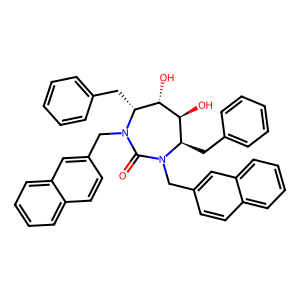

In [7]:
#@title CELL 7: Prepare ligand for docking ══════════════════════════════════════
#
# Strategy:
#   3D coordinates  → ligand.pdb  (crystal pose — best starting geometry)
#   Bond orders     → mol         (RCSB SDF — correct by construction)
#   Combined via AssignBondOrdersFromTemplate: no EmbedMolecule, no hanging.

print("Step 1: Building ligand — 3D coords from crystal PDB, bond orders from mol...")
print(f"  mol (RCSB SDF) heavy atoms : {mol.GetNumAtoms()}")

pdb_mol = Chem.MolFromPDBFile('ligand.pdb', removeHs=True, sanitize=False)
if pdb_mol is None:
    raise ValueError("Could not load ligand.pdb")
print("  Loaded ligand.pdb")

# Partial sanitize — restores aromaticity without failing on PDB valence quirks
san_flags = Chem.SanitizeFlags.SANITIZE_ALL ^ Chem.SanitizeFlags.SANITIZE_PROPERTIES
Chem.SanitizeMol(pdb_mol, san_flags)
print(f"  PDB ligand heavy atoms     : {pdb_mol.GetNumAtoms()}")

if mol.GetNumAtoms() != pdb_mol.GetNumAtoms():
    raise ValueError(
        f"Atom count mismatch: mol has {mol.GetNumAtoms()}, "
        f"pdb_mol has {pdb_mol.GetNumAtoms()}.\n"
        "Check that ligand_resname and ligand.pdb refer to the same molecule.")

try:
    lig_mol = AllChem.AssignBondOrdersFromTemplate(mol, pdb_mol)
    print("  Bond orders assigned ✅")
except ValueError:
    print("  Retrying without stereochemistry...")
    _tmpl = copy.deepcopy(mol)
    Chem.RemoveStereochemistry(_tmpl)
    try:
        lig_mol = AllChem.AssignBondOrdersFromTemplate(_tmpl, pdb_mol)
        print("  Bond orders assigned (stereo-stripped) ✅")
    except ValueError:
        raise ValueError(
            "AssignBondOrdersFromTemplate failed.\n"
            "Check that ligand_resname matches the ligand in ligand.pdb.")

# Add H with 3D placement (no EmbedMolecule needed — coords already exist)
lig_mol = Chem.AddHs(lig_mol, addCoords=True)
AllChem.MMFFOptimizeMolecule(lig_mol, maxIters=500, mmffVariant='MMFF94')

print(f"\n  Atoms (with H):   {lig_mol.GetNumAtoms()}")
print(f"  Rotatable bonds:  {Descriptors.NumRotatableBonds(lig_mol)}")
print(f"  H-bond donors:    {Descriptors.NumHDonors(lig_mol)}")
print(f"  H-bond acceptors: {Descriptors.NumHAcceptors(lig_mol)}")
print(f"  MW:               {Descriptors.MolWt(lig_mol):.1f} Da")

# ── save SDF ──────────────────────────────────────────────────────────────────
writer = Chem.SDWriter('ligand_H.sdf')
writer.write(lig_mol)
writer.close()
print("\nStep 2: Saved → ligand_H.sdf")

# ── convert to PDBQT using meeko ──────────────────────────────────────────────
print("Step 3: Converting to PDBQT with Meeko...")
try:
    from meeko import MoleculePreparation, PDBQTWriterLegacy
    preparator   = MoleculePreparation()
    mol_setups   = preparator.prepare(lig_mol)
    pdbqt_str, is_ok, err = PDBQTWriterLegacy.write_string(mol_setups[0])
    if not is_ok:
        raise RuntimeError(f"Meeko write error: {err}")
    with open('ligand.pdbqt', 'w') as f:
        f.write(pdbqt_str)
    print("  Meeko → ligand.pdbqt ✅")
    if os.path.exists('ligand.pdbqt'):
        print(f"  Confirmed: ligand.pdbqt exists with size {os.path.getsize('ligand.pdbqt')} bytes")
    else:
        print("  Warning: ligand.pdbqt was not found after writing.")
except ImportError as e:
    raise ImportError(f"Missing dependency: {e}\nFix: !pip install gemmi")
except Exception as e:
    print(f"  Error during Meeko conversion: {e}")
    raise

# ── 2D display ────────────────────────────────────────────────────────────────
print("\nLigand structure going into docking:")
_dm = copy.deepcopy(mol)
AllChem.Compute2DCoords(_dm)
buf = BytesIO()
Draw.MolToImage(_dm, size=(300, 300)).save(buf, format='PNG')
display(Image(data=buf.getvalue()))

display(HTML("""
<div style='padding:10px;background:#f0fff0;border-left:4px solid #4CAF50;
            border-radius:6px;font-size:13px'>
<p style=\"color:black;\"><b>Connection to Section 6:</b> The H-bond donors/acceptors above
are the same properties you adjusted with the sliders. Rotatable bonds determine
how many conformations Vina will explore — more = longer search.</p>
</div>"""))

In [8]:
#@title ══ CELL 8: Define docking box  ═════════════

import numpy as np
import py3Dmol
import MDAnalysis as mda

# ── load ligand coordinates ──────────────────────────────────────────────────
u = mda.Universe('ligand.pdb')
coords = u.atoms.positions

# ── compute docking center ───────────────────────────────────────────────────
centre = coords.mean(axis=0)

# ── compute ligand extent ────────────────────────────────────────────────────
span = coords.max(axis=0) - coords.min(axis=0)

# ── 🔥 OPTIMIZED BOX (KEY SPEED FIX) ─────────────────────────────────────────
# was: +10.0 (too large, slows Vina significantly)
# now: +5.0 (balanced accuracy + speed)
box_size = span + 5.0

print(f"Crystal ligand centre : {centre[0]:.2f}, {centre[1]:.2f}, {centre[2]:.2f}")
print(f"Ligand span           : {span[0]:.1f} × {span[1]:.1f} × {span[2]:.1f} Å")
print(f"Search box (OPTIMIZED): {box_size[0]:.1f} × {box_size[1]:.1f} × {box_size[2]:.1f} Å")

# ── visualize docking box ────────────────────────────────────────────────────
view = py3Dmol.view(width=800, height=600)
view.addModel(open(f'{PDB_ID}.pdb').read(), 'pdb')
view.setStyle({'cartoon': {'color': 'lightgray'}})

view.addModel(open('ligand.pdb').read(), 'pdb')
view.setStyle({'resn': ligand_resname}, {'stick': {'colorscheme': 'cyanCarbon'}})

view.addBox({
    'center': {
        'x': float(centre[0]),
        'y': float(centre[1]),
        'z': float(centre[2])
    },
    'dimensions': {
        'w': float(box_size[0]),
        'h': float(box_size[1]),
        'd': float(box_size[2])
    },
    'color': 'blue',
    'opacity': 0.25
})

view.zoomTo()
view.show()

# ── Vina settings ────────────────────────────────────────────────────────────
# User-configurable Vina exhaustiveness
VINA_EXHAUSTIVENESS = 2 # @param {type:"integer"}

# ── write config file ────────────────────────────────────────────────────────
config = f"""receptor = protein_H.pdbqt
ligand   = ligand.pdbqt

center_x = {centre[0]:.3f}
center_y = {centre[1]:.3f}
center_z = {centre[2]:.3f}

size_x = {box_size[0]:.1f}
size_y = {box_size[1]:.1f}
size_z = {box_size[2]:.1f}

exhaustiveness = {VINA_EXHAUSTIVENESS}
num_modes = 9
energy_range = 3
"""

with open('vina_config.txt', 'w') as f:
    f.write(config)

print("\nSaved → vina_config.txt\n")
print(config)

Crystal ligand centre : -9.19, 15.91, 27.95
Ligand span           : 10.0 × 7.5 × 17.1 Å
Search box (OPTIMIZED): 15.0 × 12.5 × 22.1 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Saved → vina_config.txt

receptor = protein_H.pdbqt
ligand   = ligand.pdbqt

center_x = -9.192
center_y = 15.906
center_z = 27.946

size_x = 15.0
size_y = 12.5
size_z = 22.1

exhaustiveness = 2
num_modes = 9
energy_range = 3



In [9]:
#@title ══ CELL 9: run the autodock map ════════════════════════════════════════════════
from vina import Vina

# SPEED FIX: Added cpu=0 to use all available CPU cores
v = Vina(sf_name='vina', cpu=0)

v.set_receptor('protein_H.pdbqt')
v.set_ligand_from_file('ligand.pdbqt')



In [10]:
#@title CELL 10 Run Vina Docking (can take a few minutes)
# Uses the optimized center and box_size from CELL 8
v.compute_vina_maps(
    center   = [float(centre[0]), float(centre[1]), float(centre[2])],
    box_size = [float(box_size[0]), float(box_size[1]), float(box_size[2])])

print(f"Running Vina docking (exhaustiveness={VINA_EXHAUSTIVENESS}, n_poses=9)...")

# Vina will now parallelize these 8 exhaustiveness steps across your CPUs
v.dock(exhaustiveness=VINA_EXHAUSTIVENESS, n_poses=9)

v.write_poses('results_direct.pdbqt', n_poses=9, overwrite=True)
print("Done → results_direct.pdbqt")

Running Vina docking (exhaustiveness=2, n_poses=9)...
Done → results_direct.pdbqt


### Docking Pose Visualization

This section allows you to interactively explore and compare the different docking poses generated by Vina with the original crystal ligand.

In [11]:
#@title CELL 11 Extract Docking Poses and Affinities
pose_data = []

with open('results_direct.pdbqt') as f:
    content = f.read()

models = content.split('MODEL')

all_docked_pdbqts = []

for i, block in enumerate(models):
    if not block.strip():
        continue

    full_block = "MODEL" + block

    affinity_match = re.search(r'REMARK VINA RESULT:\s+([-\d.]+)', full_block)
    if affinity_match:
        pose_data.append({
            'pose': i,
            'affinity_kcal': float(affinity_match.group(1))
        })

    all_docked_pdbqts.append(full_block)

In [34]:
#@title CELL 12 Interactive Docking Pose Visualization
import re
import os
import py3Dmol
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# -----------------------------
# SAFE PDBQT → CLEAN PDB
# (fixes "fragment ligand" issue)
# -----------------------------
def pdbqt_to_pdb_block(pdbqt_text):
    pdb_lines = []
    for line in pdbqt_text.splitlines():
        if line.startswith(("ATOM", "HETATM")):
            pdb_lines.append(line[:66] + "\n")  # remove PDBQT junk columns
    return "".join(pdb_lines)


# -----------------------------
# PARSE VINA OUTPUT CORRECTLY
# -----------------------------
pose_data = []
all_docked_pdbs = []

with open("results_direct.pdbqt") as f:
    content = f.read()

models = content.split("MODEL")[1:]

for i, block in enumerate(models, 1):
    affinity = re.search(r"REMARK VINA RESULT:\s+([-\d.-]+)", block)

    if affinity:
        pose_data.append({
            "pose": i,
            "affinity_kcal": float(affinity.group(1))
        })

    pdb_block = pdbqt_to_pdb_block("MODEL" + block)
    all_docked_pdbs.append(pdb_block)


# -----------------------------
# VISUALIZATION FUNCTION
# -----------------------------
_dock_out_viz = widgets.Output()

def _show_docked_pose(pose_idx):

    view = py3Dmol.view(width=800, height=600)
    view.setBackgroundColor("white")

    # Protein
    view.addModel(open(f"{PDB_ID}.pdb").read(), "pdb")
    view.setStyle({"model": 0}, {"cartoon": {"color": "lightgray", "opacity": 0.6}})

    # Crystal ligand
    view.addModel(open("ligand.pdb").read(), "pdb")
    view.setStyle({"model": 1}, {"stick": {"colorscheme": "cyanCarbon"}})
    view.addLabel("Crystal Ligand", {"fontColor": "cyan"}, {"model": 1})

    # Docked pose (FULL STRUCTURE FIX)
    if all_docked_pdbs:
        view.addModel(all_docked_pdbs[pose_idx], "pdb")
        view.setStyle({"model": 2}, {"stick": {"colorscheme": "greenCarbon"}})

        view.addLabel(
            f"Pose {pose_idx+1} | {pose_data[pose_idx]['affinity_kcal']:.2f} kcal/mol",
            {"fontColor": "green"},
            {"model": 2}
        )

    # IMPORTANT: zoom on full ligand, not residue filter
    view.zoomTo()

    with _dock_out_viz:
        clear_output(wait=True)
        view.show()


# -----------------------------
# UI
# -----------------------------
if all_docked_pdbs:

    selector = widgets.Dropdown(
        options=[(f"Pose {p['pose']} ({p['affinity_kcal']:.2f})", i)
                 for i, p in enumerate(pose_data)],
        value=0,
        description="Pose:"
    )

    selector.observe(lambda c: _show_docked_pose(c.new), names="value")

    display(HTML("<h3>Docking Pose Viewer (FIXED FULL STRUCTURE)</h3>"))
    display(selector)

    _show_docked_pose(0)
    display(_dock_out_viz)

else:
    display(HTML("<b style='color:red'>No poses found</b>"))

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [13]:
#@title CELL 13 Sorted Docking Poses and Affinities
import pandas as pd
from IPython.display import display

# -----------------------------
# Build DataFrame from poses
# -----------------------------
pose_df = pd.DataFrame(pose_data)

# Safety check
if len(pose_df) == 0:
    print("No pose data found.")
else:
    # Sort by binding affinity (most negative = best)
    pose_df = pose_df.sort_values(by="affinity_kcal")

    # Add rank column
    pose_df["rank"] = range(1, len(pose_df) + 1)

    # Reorder columns for readability
    pose_df = pose_df[["rank", "pose", "affinity_kcal"]]

    # Rename for clean display
    pose_df.columns = ["Rank", "Pose ID", "Binding Affinity (kcal/mol)"]

    display(pose_df)

,Rank,Pose ID,Binding Affinity (kcal/mol)
0,1,1,-10.271
1,2,2,-10.151
2,3,3,-9.737
3,4,4,-9.530


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Docking Pose Validation using RMSD

RMSD scores are calculated using ALLCHEM and raw RMSD based on pdb coordinates as they are to compare the best AutoDock Vina docked pose with the original crystallized ligand.

In [14]:
# ══ NEW VALIDATION CELL: True RDKit Graph-Matched RMSD ════════════════════
from rdkit import Chem
from rdkit.Chem import AllChem
import meeko

print("Extracting your true 46-atom docking pose...")
try:
    # 1. Parse the Vina output structure using Meeko
    pdbqt_mol = meeko.PDBQTMolecule.from_file("results_direct.pdbqt", skip_typing=True)
    rdkit_mols = meeko.RDKitMolCreate.from_pdbqt_mol(pdbqt_mol)

    if rdkit_mols and len(rdkit_mols) > 0:
        # 🟢 FIXED: Isolate the single top-ranked docked pose object (Index 0)
        docked_pose = rdkit_mols[0]

        # 2. Use your pristine 'mol' from Cell 5 as the true reference structure
        # Remove hydrogens from both structures to perform a strict heavy-atom check
        ref_heavy = Chem.RemoveHs(mol)
        dock_heavy = Chem.RemoveHs(docked_pose)

        print(f"  -> Reference Heavy Atoms: {ref_heavy.GetNumAtoms()}")
        print(f"  -> Docked Heavy Atoms:    {dock_heavy.GetNumAtoms()}")

        # 3. Calculate the true shape-alignment RMSD (ignores all name/number mismatches)
        true_rmsd = AllChem.GetBestRMS(dock_heavy, ref_heavy)

        print("\n🎯 DEFINITIVE BENCHMARK RESULT:")
        print(f"=========================================")
        print(f"🏆 True Validation Heavy-Atom RMSD: {true_rmsd:.3f} Å")
        print(f"=========================================")
    else:
        print("❌ Error: No docking poses found inside the list matrix.")

except Exception as e:
    print(f"❌ Validation calculation crashed: {e}")


Extracting your true 46-atom docking pose...
  -> Reference Heavy Atoms: 46
  -> Docked Heavy Atoms:    46

🎯 DEFINITIVE BENCHMARK RESULT:
🏆 True Validation Heavy-Atom RMSD: 2.322 Å


In [15]:
#@title ══ NEW CELL: Extract Top Docked Pose and Download ════════════════
from meeko import PDBQTMolecule, RDKitMolCreate
from rdkit import Chem
from google.colab import files

print("Step 1: Parsing Vina PDBQT output file with updated Meeko...")
try:
    # Read the raw docking coordinates using correct modern Meeko class
    pdbqt_mol = PDBQTMolecule.from_file("results_direct.pdbqt", skip_typing=True)

    # Extract the RDKit molecule objects directly from the PDBQT object matrix
    rdkit_mols = RDKitMolCreate.from_pdbqt_mol(pdbqt_mol)

    if rdkit_mols and len(rdkit_mols) > 0:
        # Isolate the absolute best-scoring conformation (Pose 1 / Index 0)
        top_pose = rdkit_mols[0]

        # NEW: Remove hydrogens to ensure consistent atom count with reference
        top_pose_heavy = Chem.RemoveHs(top_pose)

        # Save it as a standard, high-quality PDB file
        output_filename = "colab_pose_1.pdb"
        # Use MolToPDBBlock to get the PDB string directly from the Mol object
        pdb_block = Chem.MolToPDBBlock(top_pose_heavy) # Use the heavy atom version
        with open(output_filename, "w") as f:
            f.write(pdb_block)
        print(f"  ✅ Created clean file: {output_filename} with {top_pose_heavy.GetNumAtoms()} atoms.")

        # Step 2: Push the file directly to your Mac browser downloads folder
        print("Step 2: Triggering browser download...")
        files.download(output_filename)
        print("  📥 Download prompt sent! Check your Downloads folder.")

    else:
        print("❌ Error: Meeko could not extract any poses from results_direct.pdbqt")

except FileNotFoundError:
    print("❌ Error: Could not find 'results_direct.pdbqt'. Did your docking run finish?")
except Exception as e:
    print(f"❌ Unexpected Error: {e}")

Step 1: Parsing Vina PDBQT output file with updated Meeko...
  ✅ Created clean file: colab_pose_1.pdb with 46 atoms.
Step 2: Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  📥 Download prompt sent to your Mac! Check your Downloads folder.


In [26]:
#@title Docked Poses pdb file Download
from meeko import PDBQTMolecule, RDKitMolCreate
from rdkit import Chem
from google.colab import files

print("Extracting clean TOP POSE (forced single structure)...")

# Load Vina output
pdbqt_mol = PDBQTMolecule.from_file("results_direct.pdbqt", skip_typing=True)

# Convert to RDKit molecules (all poses) using RDKitMolCreate
rdkit_mols = RDKitMolCreate.from_pdbqt_mol(pdbqt_mol)

# Check the length of the list of RDKit molecules
if not rdkit_mols or len(rdkit_mols) == 0:
    raise ValueError("No poses found in Vina output.")

print(f"Total poses detected: {len(rdkit_mols)}")

# ── TAKE ONLY BEST POSE (index 0) ──
best_pose = rdkit_mols[0]

# Remove hydrogens
best_pose = Chem.RemoveHs(best_pose)

# ── FORCE SINGLE CONFORMER CLEANUP ──
# Explicitly specify confId=0 to ensure only the first conformer is written.
# This handles multiple models more robustly than string manipulation.
mol_block = Chem.MolToPDBBlock(best_pose, confId=0)

# The previous 'HARD CLEAN' for MODEL/ENDMDL lines is now redundant
# because confId=0 ensures only a single model block is generated.
# However, to be absolutely safe, we can keep a check for unexpected models.
if "MODEL" in mol_block:
    # This case should ideally not be reached after specifying confId=0.
    # If it is, there might be a deeper issue with the Mol object's internal structure.
    print("Warning: 'MODEL' keyword still present after confId=0. Attempting final string clean-up.")
    clean_lines = [
        line for line in mol_block.splitlines()
        if not line.startswith("MODEL") and not line.startswith("ENDMDL")
    ]
    clean_pdb = "\n".join(clean_lines) + "\n"
else:
    clean_pdb = mol_block

# Save final file
output_file = "colab_pose_1.pdb"
with open(output_file, "w") as f:
    f.write(clean_pdb)

print(f"Saved CLEAN pose → {output_file}")
print(f"Atoms: {best_pose.GetNumAtoms()}")

# ══ DOWNLOAD CLEAN TOP POSE ════════════════════════════════════════
output_file = "colab_pose_1.pdb"
print(f"Triggering download for: {output_file}")
files.download(output_file)
print("  📥 Download prompt sent! Check your Downloads folder.")

Extracting clean TOP POSE (forced single structure)...
Total poses detected: 1
Saved CLEAN pose → colab_pose_1.pdb
Atoms: 46
Triggering download for: colab_pose_1.pdb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  📥 Download prompt sent! Check your Downloads folder.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
#@title Coordinate Extraction
import numpy as np
from rdkit import Chem
import MDAnalysis as mda

PDB_ID = "1HVR"
ligand_resname = "XK2"

# ═══════════════════════════════════════════════════════════════════════
# 1. EXTRACT REFERENCE LIGAND FROM 1HVR.pdb (crystal structure)
# ═══════════════════════════════════════════════════════════════════════

print("Extracting reference ligand from 1HVR.pdb...")

universe = mda.Universe(f"{PDB_ID}.pdb")
lig_sel = universe.select_atoms(f"resname {ligand_resname}")

if lig_sel.n_atoms == 0:
    raise ValueError("Ligand not found in 1HVR.pdb")

lig_sel.write("ref_ligand.pdb")

ref_mol = Chem.MolFromPDBFile("ref_ligand.pdb", removeHs=True, sanitize=False)
ref_conf = ref_mol.GetConformer()

ref_coords = np.array([
    list(ref_conf.GetAtomPosition(i))
    for i in range(ref_mol.GetNumAtoms())
])

print(f"Reference ligand atoms: {len(ref_coords)}")

# ═══════════════════════════════════════════════════════════════════════
# 2. EXTRACT DOCKED LIGAND (FROM results_direct.pdbqt)
# ═══════════════════════════════════════════════════════════════════════

from meeko import PDBQTMolecule, RDKitMolCreate

print("\nExtracting docked ligand poses...")

pdbqt_mol = PDBQTMolecule.from_file("results_direct.pdbqt", skip_typing=True)
dock_mols = RDKitMolCreate.from_pdbqt_mol(pdbqt_mol)

print(f"Docked poses found: {len(dock_mols)}")

# ONLY TAKE TOP POSE (pose 0 = best Vina score)
dock_mol = Chem.RemoveHs(dock_mols[0])
dock_conf = dock_mol.GetConformer()

dock_coords = np.array([
    list(dock_conf.GetAtomPosition(i))
    for i in range(dock_mol.GetNumAtoms())
])

print(f"Docked ligand atoms: {len(dock_coords)}")

# ═══════════════════════════════════════════════════════════════════════
# 3. BUILD TABLES
# ═══════════════════════════════════════════════════════════════════════

ref_table = np.column_stack([np.arange(len(ref_coords)), ref_coords])
dock_table = np.column_stack([np.arange(len(dock_coords)), dock_coords])

print("\n✔ Reference ligand (crystal) + docked ligand extracted")

Extracting reference ligand from 1HVR.pdb...


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(


Reference ligand atoms: 46

Extracting docked ligand poses...
Docked poses found: 1
Docked ligand atoms: 46

✔ Reference ligand (crystal) + docked ligand extracted


In [17]:
import numpy as np
from rdkit import Chem
import MDAnalysis as mda
from meeko import PDBQTMolecule, RDKitMolCreate

# The PDB_ID and ligand_resname are configured globally in an earlier cell
# For example, from cell `2PZOvFHMKFTU`:
# PDB_ID         = "1HVR"
# ligand_resname = "XK2"

print("Step 1: Re-extracting ligand coordinates directly for consistency...")

# 1. EXTRACT REFERENCE LIGAND FROM 1HVR.pdb (crystal structure)
# This ensures ref_coords is freshly defined for this cell
universe = mda.Universe(f"{PDB_ID}.pdb")
lig_sel = universe.select_atoms(f"resname {ligand_resname}")

if lig_sel.n_atoms == 0:
    raise ValueError("Reference Ligand not found in 1HVR.pdb. Check PDB_ID and ligand_resname.")

# Ensure 'ref_ligand.pdb' is written and read consistently
lig_sel.write("ref_ligand.pdb")
ref_mol = Chem.MolFromPDBFile("ref_ligand.pdb", removeHs=True, sanitize=False)
ref_conf = ref_mol.GetConformer()

ref_coords = np.array([
    list(ref_conf.GetAtomPosition(i))
    for i in range(ref_mol.GetNumAtoms())
])

# 2. EXTRACT DOCKED LIGAND (FROM results_direct.pdbqt)
# This ensures dock_coords is freshly defined for this cell
pdbqt_mol = PDBQTMolecule.from_file("results_direct.pdbqt", skip_typing=True)
dock_mols = RDKitMolCreate.from_pdbqt_mol(pdbqt_mol)

if not dock_mols:
    raise ValueError("No docked poses found in results_direct.pdbqt.")

# ONLY TAKE TOP POSE (pose 0 = best Vina score)
dock_mol = Chem.RemoveHs(dock_mols[0])
dock_conf = dock_mol.GetConformer()

dock_coords = np.array([
    list(dock_conf.GetAtomPosition(i))
    for i in range(dock_mol.GetNumAtoms())
])

print(f"Reference atoms: {len(ref_coords)}")
print(f"Docked atoms:    {len(dock_coords)}")

if ref_coords.shape != dock_coords.shape:
    raise ValueError("Atom count mismatch — cannot compute RMSD")

Step 1: Re-extracting ligand coordinates directly for consistency...
Reference atoms: 46
Docked atoms:    46


In [18]:
#@title ══  Pure Coordinate RMSD ═══════════

import math

print("\nStep 2: Computing PURE manual RMSD (no alignment)")

n = len(ref_coords)
sum_sq = 0.0

print("\nIdx     Distance (Å)")
print("-" * 25)

for i in range(n):
    dx = ref_coords[i, 0] - dock_coords[i, 0]
    dy = ref_coords[i, 1] - dock_coords[i, 1]
    dz = ref_coords[i, 2] - dock_coords[i, 2]

    dist = math.sqrt(dx*dx + dy*dy + dz*dz)
    sum_sq += dist**2

    print(f"{i:<5}{dist:15.3f}")

manual_rmsd = math.sqrt(sum_sq / n)

print("\n===================================")
print("PURE MANUAL RMSD (PDB COORDS ONLY)")
print("-----------------------------------")
print(f"RMSD: {manual_rmsd:.3f} Å")
print("===================================")


Step 2: Computing PURE manual RMSD (no alignment)

Idx     Distance (Å)
-------------------------
0              4.141
1              4.109
2              3.868
3              5.070
4              5.299
5              5.398
6              7.218
7              6.265
8              7.740
9              8.138
10             7.723
11             5.248
12            10.091
13             8.977
14             7.464
15             9.943
16            11.760
17            13.579
18            14.768
19            14.135
20            12.145
21            10.320
22             5.997
23             6.591
24             7.111
25             9.070
26             7.402
27             6.708
28             5.343
29             5.311
30             7.444
31             8.889
32             8.800
33             7.475
34             5.401
35             5.493
36             5.124
37             5.654
38             7.341
39            10.117
40            11.975
41            13.019
42            12.29